In [1]:
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import scanpy as sc

In [6]:
import scvi

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import gc

In [8]:
#pip install scikit-misc --force

In [9]:
print(scvi.__version__)

1.1.1


In [10]:
adata = sc.read_h5ad('Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [11]:
adata.var.columns

Index(['mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0',
       'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0',
       'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0',
       'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0',
       'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0',
       'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0',
       'feature_name-1-0-0-0-0', 'feature_reference-1-0-0-0-0',
       'feature_biotype-1-0-0-0', 'feature_is_filtered-1-0-0-0',
       'feature_name-1-0-0-0', 'feature_reference-1-0-0-0', 'mt-1-0-0-0',
       'rb-1-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0',
       'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'mt-1-0-0',
       'rb-1-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0',
       'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0',
       'feature_biotype-1-0', 'feature_is_filtered-1-0', 'feature_name-1-0',
       'feature_reference-1-0', 'mt-1-0', 

In [12]:
adata.obs.columns

Index(['tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source',
       'doublet_scores', 'predicted_doublets', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb',
       'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation',
       'disease_state', 'age', 'batch', 'n_genes', 'batch_2', '_scvi_batch',
       'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels',
       'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI',
       'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined',
       'nhood_kth_distance'],
      dtype='object')

In [13]:
adata.obs['batch'].value_counts()

batch
0    579351
1    246528
2     93555
Name: count, dtype: int64

In [14]:
sc.pp.highly_variable_genes(
    adata, 
    flavor="seurat_v3", 
    n_top_genes=2000, 
    layer="counts", 
    batch_key="dataset_id",
    subset=True
)

In [15]:
adata.obs[['dataset_id', 'tissue']].value_counts()

dataset_id                   tissue
Perez_2022                   Blood     688094
GSE157278_Hong_2020          Blood      53732
Qian_Yue_Zhang_2022          Blood      51585
GSE163314_Lefferts_2021      Blood      47708
E-MTAB-9492_Penkava_2020     Blood      32952
Martin_JIA_2019              Blood      24019
GSE134809_Martin_et_al_2019  Blood      20584
Braga_asthma_CD4             Blood        760
Name: count, dtype: int64

In [16]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="donor_id")

/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [17]:
vae = scvi.model.SCVI(adata, n_layers=3, n_latent=30, gene_likelihood="nb")

In [18]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])

In [19]:
max_epochs_scvi

9

In [20]:
vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 9/9: 100%|██████████| 9/9 [09:31<00:00, 63.94s/it, v_num=1, train_loss_step=387, train_loss_epoch=420]

`Trainer.fit` stopped: `max_epochs=9` reached.


Epoch 9/9: 100%|██████████| 9/9 [09:31<00:00, 63.52s/it, v_num=1, train_loss_step=387, train_loss_epoch=420]


In [21]:
vae.save("scVI_Model_Myeloid_B_T_From_PBMC", overwrite=True, save_anndata=True)

In [22]:
vae = scvi.model.SCVI.load("scVI_Model_Myeloid_B_T_From_PBMC")

INFO     File scVI_Model_Myeloid_B_T_From_PBMC/model.pt already downloaded                                         


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [23]:
adata = sc.read_h5ad('Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [24]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [25]:
sc.pp.neighbors(adata, use_rep="X_scVI")

In [26]:
adata

AnnData object with n_obs × n_vars = 919434 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0', 'feature_name-1-0-0-0-0', 'feat

In [ ]:
sc.tl.leiden(adata, resolution=0.6)

IOStream.flush timed out


In [ ]:
sc.tl.umap(adata, min_dist=0.3, neighbors_key="neighbors", spread =1)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda

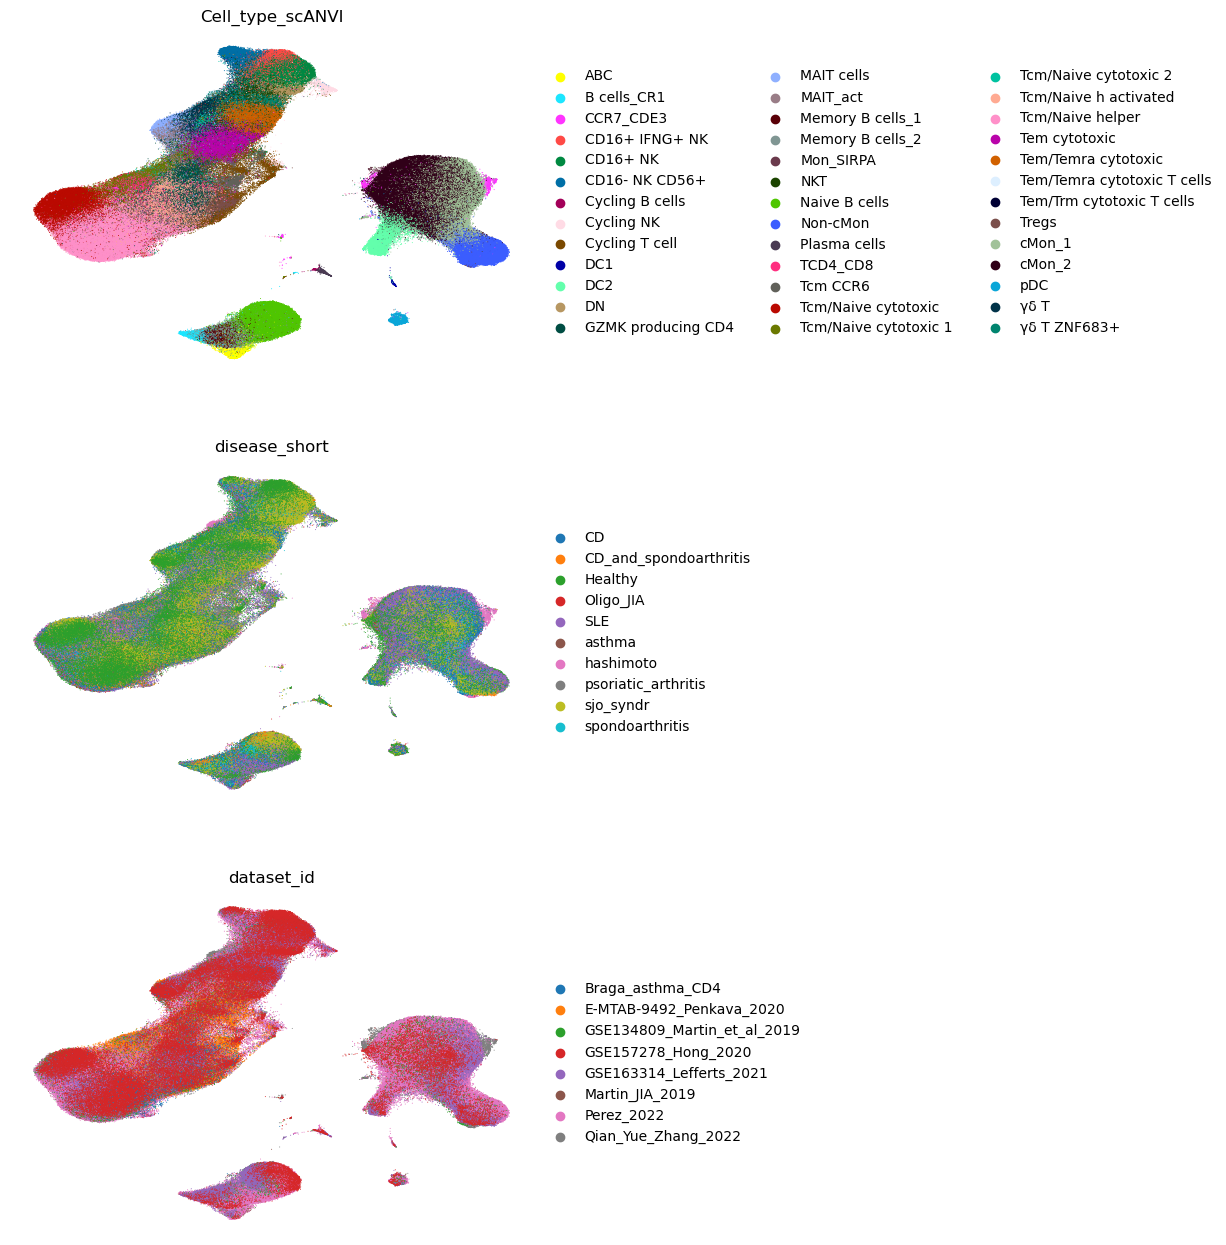

In [28]:
sc.pl.umap(
    adata,
    color=['Cell_type_scANVI', 'disease_short', 'dataset_id'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    #legend_loc="on data"
)

In [29]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
   # x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    modelname = "{fname}_scvi_model".format(fname=file_name)
    #np.save(data_dir + outname, x_scanvi)
    vae.save(data_dir + modelname, overwrite=True)
    pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])

In [30]:
 save_x_scvi(adata=adata, data_dir="result_scvi/Myeloid_B_T_From_PBMC/", file_name="scVI_Myeloid_B_T_From_PBMC", vae=vae)

In [ ]:
2+3